In [88]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import matplotlib.pyplot as plt
import numpy as np

In [89]:
sim = Simulation("DarkSignal")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# Single-pixel exposures

numExposures = 1000
sim["ObservingParameters/NumExposures"] = numExposures
sim["SubField/NumRows"] = 1
sim["SubField/NumColumns"] = 1

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Enable dark signal

sim["CCD/IncludeDarkSignal"] = "yes"

# output = sim.run(removeOutputFile = True)

# DSNU

In [90]:
sim["CCD/DarkSignal/Stability"] = 0
outputWithDark = sim.run(removeOutputFile = True)


2019-05-29 13:59:54 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-29 13:59:54 WARNING Camera: No star positions to write to HDF5 file.



In [91]:
sim["CCD/IncludeDarkSignal"] = "no"
outputWithoutDark = sim.run(removeOutputFile = True)


2019-05-29 13:59:58 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-29 13:59:58 WARNING Camera: No star positions to write to HDF5 file.



In [92]:
dark = np.array([])

for exposure in range(numExposures):
    
    dark = np.append(dark, outputWithDark.getImage(exposure)[0][0] - outputWithoutDark.getImage(exposure)[0][0])

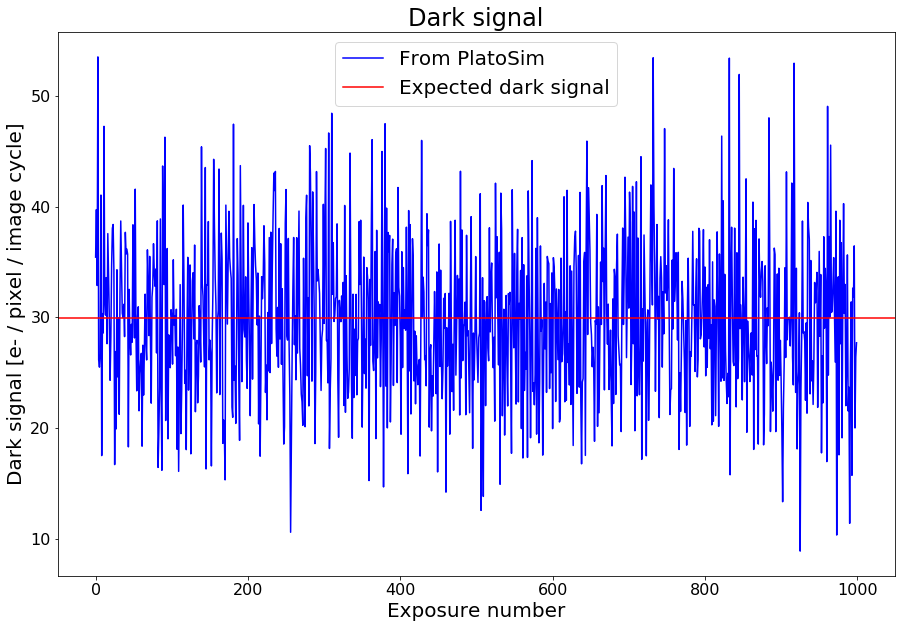

In [93]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(dark, "b", label = "From PlatoSim")



#########
# Average
#########

plt.axhline(y = expectedDarkSignal, color = "r", label = "Expected dark signal")



########
# Layout
########

plt.title("Dark signal", fontsize = 24)
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Dark signal [e- / pixel / image cycle]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

In [94]:
cycleTime = sim["ObservingParameters/ExposureTime"] + sim["CCD/NumRows"] * (sim["CCD/NumColumns"] / 2 * sim["CCD/SerialTransferTime"] * 1E-9 + sim["CCD/ParallelTransferTime"]* 1E-6)
expectedDarkSignal = sim["CCD/DarkSignal/DarkCurrent"] * cycleTime

dsnu = sim["CCD/DarkSignal/DSNU"] / 100.0

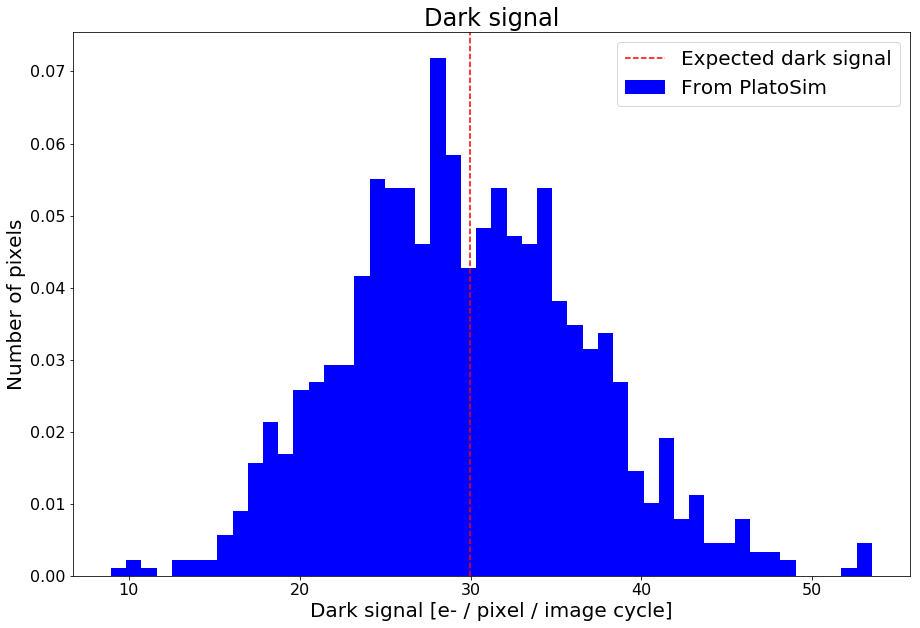

In [95]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

plt.hist(dark, 50, density = True, color = "b", label = "From PlatoSim")



#####################
# Normal distribution
#####################

mu = expectedDarkSignal
sigma = expectedDarkSignal * dsnu
# x = np.arange(poisson.ppf(0.01, mu),  poisson.ppf(0.99, mu))
# ax.plot(x, poisson.pmf(x, mu), "r", label='Poisson distribution')

label = "N(D$_0$, D$_0 \cdot$ DSNU)"
plt.axvline(x = expectedDarkSignal, color = "r", linestyle = "dashed", label = "Expected dark signal")



########
# Layout
########

plt.title("Dark signal", fontsize = 24)
plt.xlabel("Dark signal [e- / pixel / image cycle]", fontsize = 20)
plt.ylabel("Number of pixels", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

# Temperature stability

In [98]:
numExposures = 1000
sim["ObservingParameters/NumExposures"] = numExposures

time = np.array([0, numExposures * cycleTime])
sim["ObservingParameters/NumExposures"] = numExposures - 2
deltaTemperature = 1
temperature = np.array([sim["CCD/NominalOperatingTemperature"], sim["CCD/NominalOperatingTemperature"] + deltaTemperature])

sim["CCD/IncludeDarkSignal"] = "yes"
sim["CCD/DarkSignal/Stability"] = 5.0
sim["CCD/DarkSignal/DSNU"] = 0

sim["CCD/Temperature"] = "FromFile"
temperatureFilename = os.environ["PLATO_WORKDIR"] + "temperature.txt"
sim["CCD/TemperatureFileName"] = temperatureFilename

np.savetxt(temperatureFilename, np.c_[time, temperature])

outputWithDark = sim.run(removeOutputFile = True)


2019-05-29 14:01:07 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-29 14:01:07 WARNING Camera: No star positions to write to HDF5 file.



In [99]:
dark = np.array([])

for exposure in range(numExposures - 2):
    
    dark = np.append(dark, outputWithDark.getImage(exposure)[0][0] - outputWithoutDark.getImage(exposure)[0][0])

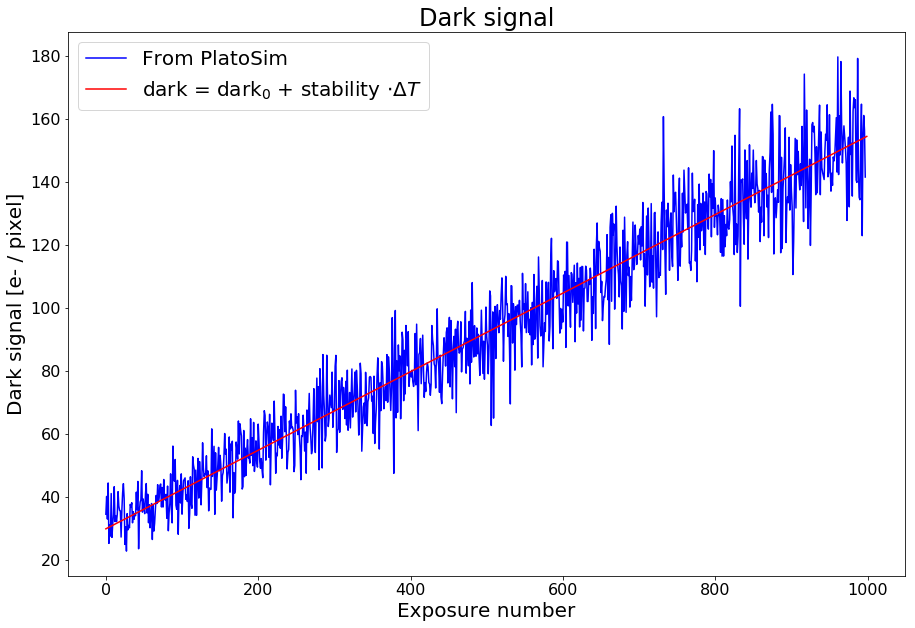

In [100]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

plt.plot(dark, color = "b", label = "From PlatoSim")



#############################################################
# Linear increase in dark signal with increase in temperature
#############################################################


slope = (temperature[-1] - temperature[0]) / (numExposures) * sim["CCD/DarkSignal/Stability"] * cycleTime
exposures = np.arange(0, numExposures)
plt.plot(expectedDarkSignal + slope * exposures, "r", label = "dark = dark$_0$ + stability $\\cdot \\Delta T$")



########
# Layout
########

plt.title("Dark signal", fontsize = 24)
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Dark signal [e- / pixel]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)